In [1]:
import numpy as np
import random
from transformers import XLMRobertaConfig, XLMRobertaModel, XLMRobertaTokenizer,XLMRobertaForSequenceClassification
import torch
from torch.utils.data import DataLoader
from torch import optim
import torch.nn.functional as F
from tqdm import tqdm
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.utils import resample
import re

/home/darrentimotius/.local/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Common functions
LABEL2INDEX = {'positive': 0, 'neutral': 1, 'negative': 2}
INDEX2LABEL = {0: 'positive', 1: 'neutral', 2: 'negative'}
NUM_LABELS = 3

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    
def count_param(module, trainable=False):
    if trainable:
        return sum(p.numel() for p in module.parameters() if p.requires_grad)
    else:
        return sum(p.numel() for p in module.parameters())
    
def get_lr(optimizer):
    for param_group in optimizer.param_groups:
        return param_group['lr']

def metrics_to_string(metric_dict):
    string_list = []
    for key, value in metric_dict.items():
        string_list.append('{}:{:.2f}'.format(key, value))
    return ' '.join(string_list)

In [3]:
set_seed(20250826)

### Load Model

In [4]:
# Load Tokenizer and Config
tokenizer = XLMRobertaTokenizer.from_pretrained('xlm-roberta-base')
config = XLMRobertaConfig.from_pretrained('xlm-roberta-base')
config.num_labels = NUM_LABELS

# Instantiate model
model = XLMRobertaForSequenceClassification.from_pretrained('xlm-roberta-base', config=config)

Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [7]:
# Processing Datasets
def load_dataset(path):
    df = pd.read_csv(path, sep='\t', header=None)
    df.columns = ['text', 'sentiment']
    df['sentiment'] = df['sentiment'].apply(lambda lab: LABEL2INDEX[lab])
    return df

def encode_dataset(df, tokenizer, no_special_token=False):
    encoded = []
    for _, row in df.iterrows():
        text = row['text']
        sentiment = row['sentiment']
        subwords = tokenizer.encode(text, add_special_tokens=not no_special_token)
        encoded.append((np.array(subwords), np.array(sentiment), text))
    return encoded

def collate_fn(batch, max_seq_len=512):
    batch_size = len(batch)
    max_len = min(max(len(x[0]) for x in batch), max_seq_len)
    
    subword_batch = np.zeros((batch_size, max_len), dtype=np.int64)
    mask_batch = np.zeros((batch_size, max_len), dtype=np.float32)
    sentiment_batch = np.zeros((batch_size, 1), dtype=np.int64)
    seq_list = []

    for i, (subwords, sentiment, raw_seq) in enumerate(batch):
        subwords = subwords[:max_len]
        subword_batch[i, :len(subwords)] = subwords
        mask_batch[i, :len(subwords)] = 1
        sentiment_batch[i, 0] = sentiment
        seq_list.append(raw_seq)

    return (
        torch.tensor(subword_batch),
        torch.tensor(mask_batch),
        torch.tensor(sentiment_batch),
        seq_list
    )

def load_dataset_csv(path):
    df = pd.read_csv(path, header=0)
    df['sentiment'] = df['sentiment'].apply(lambda lab: LABEL2INDEX[lab])
    return df

def load_dataset_empty(path):
    df = pd.read_csv(path)
    df['sentiment'] = 'neutral'
    return df

In [8]:
train_dataset_path = '../../data/combined/train_combined.csv'
valid_dataset_path = '../../data/combined/valid_combined.csv'
test_dataset_path = '../../data/combined/test_combined.csv'
test_labeling_path = '../../data/combined/test_combined_unmasked.csv'

In [9]:
train_df = load_dataset_csv(train_dataset_path)
valid_df = load_dataset_csv(valid_dataset_path)
test_df  = load_dataset_csv(test_dataset_path)
test_label_df = load_dataset_csv(test_labeling_path)

In [10]:
train_df

,text,sentiment
0,"ditinggalkan gerindra , nasib nya - ass diujun...",1
1,"suasana makan di saung , dengan pohon-pohon hi...",0
2,pertama kali saya makan steak hotel by holycow...,0
3,"pihak toko tidak jelas, di minta barang a yg d...",2
4,"untuk sebuah usaha homemade cheesecake , penca...",0
...,...,...
15723,"baru di pakai dgn pemakaian priNegativei, stan...",2
15724,Tipis banget bahan parasutnya. Dan tidak ada k...,2
15725,semua makanan yang pedas itu tidak enak tolong...,2
15726,mau marah-marah ke indosat rasanya .,2


In [11]:
# Casefolding
def casefold_text(text):
    return text.lower()

# Remove URLs
def remove_urls(text):
    return re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)

# Remove extra whitespace
def remove_extra_whitespace(text):
    return ' '.join(text.split())

# Remove repeated characters
def remove_repeated_characters(text):
    return re.sub(r'(.)\1{2,}', r'\1\1', text)

# Remove emojis
def remove_emojis(text):
    emoji_pattern = re.compile(
        "["
        "\U0001F600-\U0001F64F"  # emoticons
        "\U0001F300-\U0001F5FF"  # symbols & pictographs
        "\U0001F680-\U0001F6FF"  # transport & map symbols
        "\U0001F700-\U0001F77F"  # alchemical symbols
        "\U0001F1E0-\U0001F1FF"  # flags (iOS)
        "]+", flags=re.UNICODE)
    return emoji_pattern.sub(r'', text)

def preprocess_text(text):
    text = casefold_text(text)
    text = remove_urls(text)
    text = remove_extra_whitespace(text)
    text = remove_repeated_characters(text)
    text = remove_emojis(text)
    return text

In [12]:
# Apply preprocessing functions
train_df['text'] = train_df['text'].apply(preprocess_text)
valid_df['text'] = valid_df['text'].apply(preprocess_text)
test_df['text'] = test_df['text'].apply(preprocess_text)
test_label_df['text'] = test_label_df['text'].apply(preprocess_text)

In [13]:
train_encoded = encode_dataset(train_df, tokenizer)
train_upsampled_encoded = encode_dataset(train_df, tokenizer)
valid_encoded = encode_dataset(valid_df, tokenizer)
test_encoded  = encode_dataset(test_df, tokenizer)
test_label_encoded = encode_dataset(test_label_df, tokenizer)

In [14]:
train_loader = DataLoader(
    train_encoded, batch_size=32, shuffle=True, num_workers=8,
    collate_fn=lambda x: collate_fn(x, max_seq_len=512)
)

valid_loader = DataLoader(
    valid_encoded, batch_size=32, shuffle=False, num_workers=8,
    collate_fn=lambda x: collate_fn(x, max_seq_len=512)
)

test_loader = DataLoader(
    test_encoded, batch_size=32, shuffle=False, num_workers=8,
    collate_fn=lambda x: collate_fn(x, max_seq_len=512)
)

test_label_loader = DataLoader(
    test_label_encoded, batch_size=32, shuffle=False, num_workers=8,
    collate_fn=lambda x: collate_fn(x, max_seq_len=512)
)

In [15]:
w2i, i2w = LABEL2INDEX, INDEX2LABEL
print(w2i)
print(i2w)

train_df

{'positive': 0, 'neutral': 1, 'negative': 2}
{0: 'positive', 1: 'neutral', 2: 'negative'}


,text,sentiment
0,"ditinggalkan gerindra , nasib nya - ass diujun...",1
1,"suasana makan di saung , dengan pohon-pohon hi...",0
2,pertama kali saya makan steak hotel by holycow...,0
3,"pihak toko tidak jelas, di minta barang a yg d...",2
4,"untuk sebuah usaha homemade cheesecake , penca...",0
...,...,...
15723,"baru di pakai dgn pemakaian prinegativei, stan...",2
15724,tipis banget bahan parasutnya. dan tidak ada k...,2
15725,semua makanan yang pedas itu tidak enak tolong...,2
15726,mau marah-marah ke indosat rasanya .,2


In [16]:
optimizer = optim.Adam(model.parameters(), lr=5e-6)
model = model.cpu()

In [17]:
def forward_sequence_classification(model, batch_data, i2w, is_test=False, device='cpu'):
    """
    Forward function for sequence classification.
    
    Parameters:
        model      : torch.nn.Module
        batch_data : tuple of (input_ids, attention_mask, [token_type_ids], labels)
        i2w        : dict, index to label mapping
        is_test    : bool, whether test mode (optional)
        device     : str or torch.device
    
    Returns:
        loss       : torch.Tensor
        list_hyp   : list of predicted labels
        list_label : list of ground truth labels
    """
    
    # Move data to tensors
    if len(batch_data) == 3:
        input_ids, attention_mask, labels = batch_data
        token_type_ids = None
    else:
        input_ids, attention_mask, token_type_ids, labels = batch_data
    
    input_ids = torch.as_tensor(input_ids).to(device)
    attention_mask = torch.as_tensor(attention_mask).to(device)
    labels = torch.as_tensor(labels).to(device)
    
    if token_type_ids is not None:
        token_type_ids = torch.tensor(token_type_ids).to(device)

    # Forward pass
    outputs = model(
        input_ids, 
        attention_mask=attention_mask, 
        token_type_ids=token_type_ids, 
        labels=labels
    )
    loss, logits = outputs[:2]

    # Get predictions
    preds = torch.argmax(logits, dim=1)
    
    list_hyp = [i2w[p.item()] for p in preds]
    list_label = [i2w[l.item()] for l in labels]

    return loss, list_hyp, list_label

def document_sentiment_metrics_fn(list_hyp, list_label):
    metrics = {}
    metrics["ACC"] = accuracy_score(list_label, list_hyp)
    metrics["F1"] = f1_score(list_label, list_hyp, average='macro')
    metrics["REC"] = recall_score(list_label, list_hyp, average='macro')
    metrics["PRE"] = precision_score(list_label, list_hyp, average='macro')
    return metrics

In [ ]:
n_epochs = 8
train_losses = []
valid_losses = []

for epoch in range(n_epochs):
    model.train()
    torch.set_grad_enabled(True)

    total_train_loss = 0
    list_hyp, list_label = [], []

    train_pbar = tqdm(train_loader, leave=True, total=len(train_loader))
    for i, batch_data in enumerate(train_pbar):
        # Forward model
        loss, batch_hyp, batch_label = forward_sequence_classification(
            model, batch_data[:-1], i2w=i2w, device='cpu'
        )

        # Update model
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        tr_loss = loss.item()
        total_train_loss += tr_loss

        # Track predictions
        list_hyp += batch_hyp
        list_label += batch_label

        current_lr = optimizer.param_groups[0]['lr']
        train_pbar.set_description(
            f"(Epoch {epoch+1}) TRAIN LOSS:{total_train_loss/(i+1):.4f} LR:{current_lr:.8f}"
        )

    # Train metrics
    metrics = document_sentiment_metrics_fn(list_hyp, list_label)
    print(f"(Epoch {epoch+1}) TRAIN LOSS:{total_train_loss/(i+1):.4f} {metrics_to_string(metrics)} "
        f"LR:{current_lr:.8f}")
    avg_train_loss = total_train_loss / (i + 1)
    train_losses.append(avg_train_loss)

    # Validation
    model.eval()
    torch.set_grad_enabled(False)

    total_loss = 0
    list_hyp, list_label = [], []

    pbar = tqdm(valid_loader, leave=True, total=len(valid_loader))
    for i, batch_data in enumerate(pbar):
        loss, batch_hyp, batch_label = forward_sequence_classification(
            model, batch_data[:-1], i2w=i2w, device='cpu'
        )

        total_loss += loss.item()
        list_hyp += batch_hyp
        list_label += batch_label

        metrics = document_sentiment_metrics_fn(list_hyp, list_label)
        pbar.set_description(
            f"VALID LOSS:{total_loss/(i+1):.4f} {metrics_to_string(metrics)}"
        )

    metrics = document_sentiment_metrics_fn(list_hyp, list_label)
    print(f"(Epoch {epoch+1}) VALID LOSS:{total_loss/(i+1):.4f} {metrics_to_string(metrics)}")
    avg_valid_loss = total_loss / (i + 1)
    valid_losses.append(avg_valid_loss)

In [18]:
train_losses = [0.5326489501488887, 0.2590593472956036, 0.19817497915535318, 0.16626891030975413, 0.1414868604236593, 0.12098960096122531, 0.09913876925867687, 0.08190075429610727, 0.06995972293491544, 0.05834885135934711, 0.05192293246902291, 0.04426760046612244, 0.04002790598386172, 0.03285460275497545]
valid_losses = [0.26384548524454715, 0.2312578692912094, 0.24309305341974383, 0.23111171435354458, 0.23538122108326323, 0.22299874374162285, 0.22799950960888377, 0.2733482051145045, 0.27634112948867223, 0.28072103620657035, 0.2894389695720747, 0.30691506417896297, 0.3080057089438572, 0.2973187387866464]

indobert_train_losses = [0.30023782882778866, 0.1515646890048089, 0.10019237433590479, 0.06453422990408007, 0.0445597056579602, 0.02852606463787426, 0.019324130131754214, 0.019178972564631983, 0, 0, 0, 0, 0, 0]
indobert_valid_losses = [0.18969435049521347, 0.1864115167559395, 0.19713674488687707, 0.2068142673008204, 0.24270513846403768, 0.2719195253645716, 0.30180912530481546, 0.30041140323690696, 0, 0, 0, 0, 0, 0]

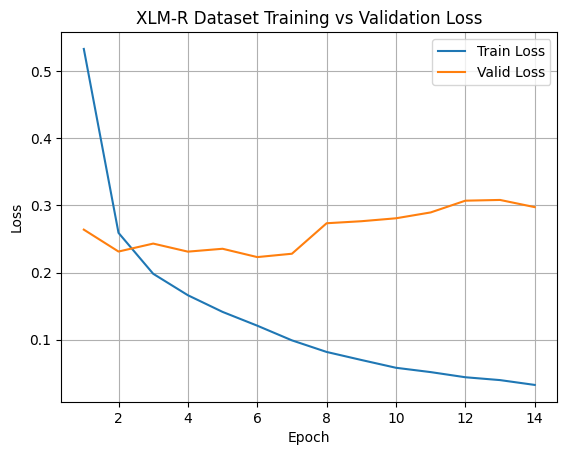

In [19]:
# plt.plot(train_losses, label='Train Loss')
plt.plot(range(1, len(train_losses) + 1), train_losses, label='Train Loss')
# plt.plot(valid_losses, label='Valid Loss')
plt.plot(range(1, len(valid_losses) + 1), valid_losses, label='Valid Loss')
plt.title("XLM-R Dataset Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.show()

In [21]:
# Evaluate on test
accuracies = []
f1_scores = []
model_paths = [
    "../../backend/model/XLM-R/xlm-model-1.pt",
    "../../backend/model/XLM-R/xlm-model-2.pt",
    "../../backend/model/XLM-R/xlm-model-3.pt",
    "../../backend/model/XLM-R/xlm-model-4.pt",
    "../../backend/model/XLM-R/xlm-model-5.pt",
    "../../backend/model/XLM-R/xlm-model-6.pt",
    "../../backend/model/XLM-R/xlm-model-7.pt",
    "../../backend/model/XLM-R/xlm-model-8.pt",
    "../../backend/model/XLM-R/xlm-model-9.pt",
    "../../backend/model/XLM-R/xlm-model-10.pt",
    "../../backend/model/XLM-R/xlm-model-11.pt",
    "../../backend/model/XLM-R/xlm-model-12.pt",
    "../../backend/model/XLM-R/xlm-model-13.pt",
    "../../backend/model/XLM-R/xlm-model-14.pt",
]

i = 0
for path in model_paths:
    i += 1
    model.load_state_dict(torch.load(path, map_location='cpu'))
    model.eval()
    torch.set_grad_enabled(False)

    list_hyp, list_label = [], []

    pbar = tqdm(test_loader, leave=True, total=len(test_loader))
    for _, batch_data in enumerate(pbar):
        _, batch_hyp, batch_label = forward_sequence_classification(model, batch_data[:-1], i2w=i2w, device='cpu')
        list_hyp += batch_hyp
        list_label += batch_label

    metrics = document_sentiment_metrics_fn(list_hyp, list_label)
    accuracies.append(metrics['ACC'])
    f1_scores.append(metrics['F1'])
    print(f"TEST Matrics {i}", end="")
    print(" | {}".format(metrics_to_string(metrics)))

100%|██████████| 62/62 [03:44<00:00,  3.62s/it]


TEST Matrics 1 | ACC:0.92 F1:0.89 REC:0.88 PRE:0.91


100%|██████████| 62/62 [03:49<00:00,  3.70s/it]


TEST Matrics 2 | ACC:0.93 F1:0.90 REC:0.90 PRE:0.91


100%|██████████| 62/62 [03:48<00:00,  3.68s/it]


...

TEST Matrics 12 | ACC:0.94 F1:0.93 REC:0.92 PRE:0.93


100%|██████████| 62/62 [04:17<00:00,  4.16s/it]


TEST Matrics 13 | ACC:0.95 F1:0.94 REC:0.93 PRE:0.94


100%|██████████| 62/62 [04:24<00:00,  4.26s/it]

TEST Matrics 14 | ACC:0.95 F1:0.94 REC:0.93 PRE:0.94


In [22]:
print(accuracies)
print(f1_scores)

[0.9186578546009151, 0.9252669039145908, 0.9278088459583121, 0.9323843416370107, 0.9359430604982206, 0.9440772750381291, 0.9430604982206405, 0.9415353329944077, 0.9466192170818505, 0.9486527707168276, 0.9471276054905948, 0.9430604982206405, 0.9486527707168276, 0.9496695475343162]
[0.893371700679165, 0.9047684844056864, 0.9112214779447451, 0.9167660299364123, 0.9154554511151595, 0.9301218862644358, 0.9301140039000146, 0.9277673791119322, 0.9340876730969249, 0.936007875409132, 0.9354219245983951, 0.9281532792217982, 0.9375663087214164, 0.9379577843842885]


In [6]:
accuracies = [0.9186578546009151, 0.9252669039145908, 0.9278088459583121, 0.9323843416370107, 0.9359430604982206, 0.9440772750381291, 0.9430604982206405, 0.9415353329944077, 0.9466192170818505, 0.9486527707168276, 0.9471276054905948, 0.9430604982206405, 0.9486527707168276, 0.9496695475343162]
f1_scores = [0.893371700679165, 0.9047684844056864, 0.9112214779447451, 0.9167660299364123, 0.9154554511151595, 0.9301218862644358, 0.9301140039000146, 0.9277673791119322, 0.9340876730969249, 0.936007875409132, 0.9354219245983951, 0.9281532792217982, 0.9375663087214164, 0.9379577843842885]

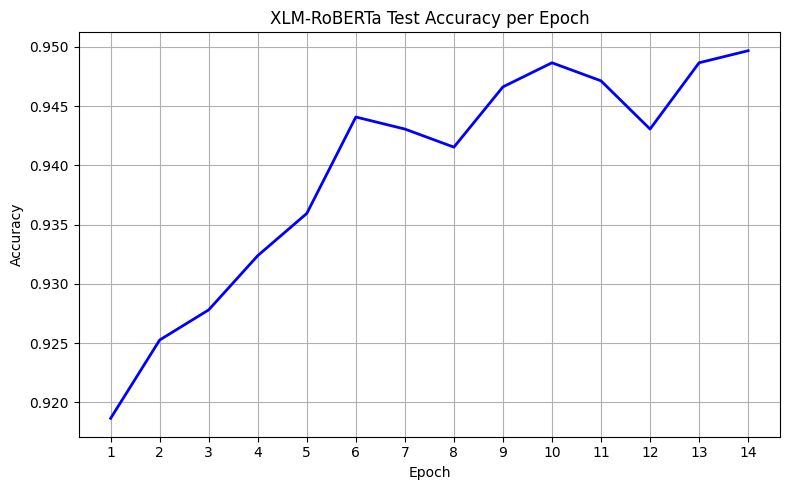

In [25]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(accuracies)+1), accuracies, color='blue', linewidth=2)  # grafik garis
plt.title("XLM-RoBERTa Test Accuracy per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.xticks(range(1, len(accuracies)+1))  # biar x axis mulai dari 1
plt.grid(True)
plt.tight_layout()
plt.show()

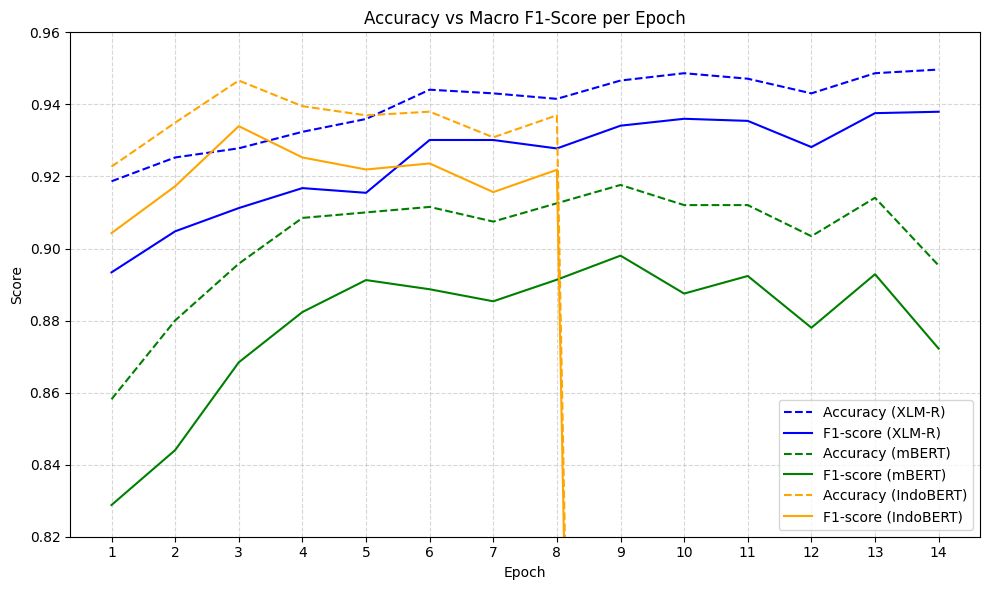

In [9]:
plt.figure(figsize=(10, 6))

epochs = range(1, 15)

indobert_accuracies = [0.9227249618708694, 0.934926283680732, 0.9466192170818505, 0.9395017793594306, 0.9369598373157092, 0.9379766141331978, 0.9308591764107779, 0.9369598373157092, 0, 0, 0, 0, 0, 0]
indobert_f1_scores = [0.9042780440855466, 0.9172780395394221, 0.9339571483174117, 0.9252724508825798, 0.9219293098527217, 0.9236033570596254, 0.9156532234585978, 0.921834515824394, 0, 0, 0, 0, 0, 0]

mbert_accuracies = [0.8581596339603457, 0.8800203355363497, 0.8957803762074225, 0.9084900864260295, 0.9100152516522624, 0.9115404168784952, 0.9074733096085409, 0.9125571936959838, 0.9176410777834265, 0.9120488052872394, 0.9120488052872394, 0.9034062023385867, 0.9140823589222166, 0.8952719877986782]
mbert_f1_scores = [0.8287989794023719, 0.8440356425501335, 0.8684060748088016, 0.88235457407258, 0.8912377789314071, 0.8886865176728681, 0.8853458752560032, 0.8913449719201582, 0.8980177822918023, 0.887487569256678, 0.8923723114756849, 0.8780091220534993, 0.8928565859232614, 0.8722136323592745]

plt.plot(epochs, accuracies, 'b--', label='Accuracy (XLM-R)')
plt.plot(epochs, f1_scores, 'b-', label='F1-score (XLM-R)')
plt.plot(epochs, mbert_accuracies, 'g--', label='Accuracy (mBERT)')
plt.plot(epochs, mbert_f1_scores, 'g-', label='F1-score (mBERT)')
plt.plot(epochs, indobert_accuracies, 'orange', linestyle='--', label='Accuracy (IndoBERT)')
plt.plot(epochs, indobert_f1_scores, 'orange', linestyle='-', label='F1-score (IndoBERT)')

plt.xticks(epochs)
plt.title("Accuracy vs Macro F1-Score per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.ylim(0.82, 0.96)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

### Testing model from Unmasked Test file and sample sentences using Epoch 14

In [34]:
# Labeling data
model.load_state_dict(torch.load("../../backend/model/XLM-R/xlm-model-14.pt", map_location='cpu'))
model.eval()
torch.set_grad_enabled(False)

total_loss, total_correct, total_labels = 0, 0, 0
list_hyp, list_label = [], []

pbar = tqdm(test_label_loader, leave=True, total=len(test_label_loader))
for i, batch_data in enumerate(pbar):
    _, batch_hyp, batch_label = forward_sequence_classification(model, batch_data[:-1], i2w=i2w, device='cpu')
    list_hyp += batch_hyp

# Save prediction
df = pd.DataFrame({'label':list_hyp}).reset_index()
df.to_csv('../../data/output/XLM-R/test-labeling.csv', index=False)

df

100%|██████████| 62/62 [04:28<00:00,  4.33s/it]


,index,label
0,0,negative
1,1,neutral
2,2,negative
3,3,positive
4,4,positive
...,...,...
1962,1962,neutral
1963,1963,positive
1964,1964,neutral
1965,1965,positive


In [35]:
# Combine and compare with true
print(test_df.columns)

test_df = test_df.copy()
test_df['sentiment'] = test_df['sentiment'].apply(lambda lab: i2w[lab])
test_df['label'] = df['label'].values
test_df.to_csv('../../data/output/XLM-R/xlm-test-label.csv', index=False)

Index(['text', 'sentiment'], dtype='object')


In [36]:
test_df = pd.read_csv('../../data/output/XLM-R/xlm-test-label.csv', header=0)
test_df

,text,sentiment,label
0,pesan 50pc dikirim 25pc padahal bayar 50pc?? s...,negative,negative
1,bagaimana cara membatalkan pesanan barang ters...,neutral,neutral
2,takdir politik ahy belum bisa ikut kontestasi ...,negative,negative
3,mantap sesuai.,positive,positive
4,produk sesuai deskripsi. good communication. f...,positive,positive
...,...,...,...
1962,"padahal udh atc bubble tapi gaada , paraah tol...",negative,neutral
1963,steak impor murah dan enak . menjadi salah sat...,positive,positive
1964,kecil-kecil cabai rawit diusung pdip jadi cagu...,neutral,neutral
1965,produk sesuai deskripsi dan pengirimannya cepat,positive,positive


              precision    recall  f1-score   support

    positive       0.97      0.93      0.95       686
     neutral       0.91      0.89      0.90       287
    negative       0.95      0.98      0.96       994

    accuracy                           0.95      1967
   macro avg       0.94      0.93      0.94      1967
weighted avg       0.95      0.95      0.95      1967



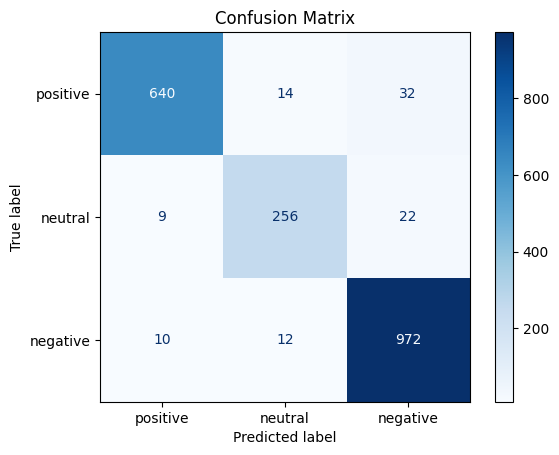

In [37]:
y_true = test_df['sentiment'].tolist()
y_pred = test_df['label'].tolist()

print(classification_report(y_true, y_pred, target_names=INDEX2LABEL.values()))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=INDEX2LABEL.values())
disp.plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()